# Projet: Analyse des données et pre-processing

Eduardo Cobos Fernandez, Sipan Bareyan Jeremy Rakotorinira, Amine Berrahma

Analyse et réduction des bias en Machine Learning

Dans ce notebook on va ...

# 0 - Introduction

**intro mi-projet edu :**

Les modèles de prédiction sont de plus en plus utilisés dans le domaine médical, notamment pour l’aide au diagnostic à partir de données patients et d’imagerie médicale. Toutefois, ces modèles peuvent hériter de biais présents dans les données utilisées pour leur apprentissage, ce qui rend nécessaire une analyse préalable de ces données.

Ce mi-projet s’appuie sur le dataset Chest X-ray NIH14 (https://www.kaggle.com/datasets/nih-chest-xrays/data), qui contient des radiographies thoraciques ainsi que des métadonnées associées aux patients, telles que l’âge, le genre et les pathologies diagnostiquées. Pour cette étape intermédiaire du projet, l’analyse se limite aux métadonnées, les images n’étant pas considérées. Un sous-ensemble de 15.000 radiographies est utilisé.

L’objectif de ce travail est d’analyser les métadonnées afin d’identifier d’éventuels biais liés à des attributs sensibles, puis d’appliquer une méthode de pré-processing pour réduire ces biais et construire un dataset transformé. Ce travail constitue une étape préparatoire au projet final, dans lequel l’impact du pré-processing sur un modèle basé sur les images sera étudié.


**intro mi-projet amine:**

L’intelligence artificielle joue un rôle important dans le domaine médical, notamment dans l’analyse d’images radiologiques. Les modèles de deep learning appliqués aux radiographies thoraciques peuvent assister les médecins dans le diagnostic de diverses maladies. Toutefois, ces systèmes peuvent reproduire ou amplifier des biais présents dans les données, ce qui peut conduire à des performances inéquitables selon certains groupes de patients.

Le cas d’usage étudié dans ce projet repose sur un sous-ensemble du dataset NIH Chest X-ray, composé de métadonnées associées à des radiographies thoraciques. Ce dataset contient des informations diverses (âge, genre...etc) ainsi que des annotations médicales indiquant la présence ou l’absence de maladies.

L’objectif principal de ce projet est d’identifier et d’analyser les biais potentiels présents dans ces données, en particulier en lien avec des attributs sensibles tels que le genre et l’âge. Pour cela, dans un premier temps une analyse descriptive est réalisée afin d’examiner la distribution des maladies selon ces groupes.

Dans un second temps, des métriques d’équité telles que la Statistical Parity Difference (SPD) et le Disparate Impact (DI) sont utilisées pour quantifier les déséquilibres observés.
Enfin, une méthode de mitigation par preprocessing, basée sur l’algorithme Reweighing, est appliquée afin de réduire ces biais et produire un dataset transformé plus équitable.

# Chargement des données

Les métadonnées du dataset Chest X-ray NIH14 sont chargées à partir du fichier fourni pour le projet. Ce fichier contient les informations associées à un sous-ensemble de 15 000 patients. (à modifier??)

In [26]:
from pathlib import Path

DATADIR= Path('Cobos_Fernandez_Eduardo')

In [2]:
### RUN ONLY ON COLAB: Put the zip file of the data in your google drive in a folder called "fairness"
confirm = input("Are you sure you are running this on Colab ? Confirm with 'y'")
if confirm != 'y':
    raise ValueError("You must confirm you are running on Colab")
# Only for Google Colab
from google.colab import drive
drive.mount('/content/drive')

# Only for Google Colab
import sys

# In your google drive, create a folder for the Fairness project
# (called here 'coursFairness')
# Copy in this folder the python file train_classifieur.py
# Copy in this folder your zipped data folder (called here 'YOUR_NAME.zip')

# Path to the folder containing the python file
drive_module_path = "/content/drive/MyDrive/fairness"
sys.path.append(drive_module_path)

# Verify the path was added
print(sys.path[-1])

project_folder = Path(drive_module_path)
zip_filename = "Cobos_Fernandez_Eduardo.zip"
zip_path = project_folder / zip_filename

if not project_folder.exists() or not zip_path.exists():
  print("Colab Config failed")
  print("Make sure you have the folder fairness folder in your google drive, and it contains the zip file named Cobos_Fernandez_Eduardo.zip")
  raise ValueError("Colab Config failed")


!cp /content/drive/MyDrive/fairness/Cobos_Fernandez_Eduardo.zip /content/
!mkdir /content/DATA/
!unzip Cobos_Fernandez_Eduardo.zip -d /content/DATA/

!pip install pandas\
  numpy\
  torchvision\
  torch\
  torchmetrics\
  tensorboard\
  pillow\
  lightning\
  matplotlib\
  scikit_learn\
  ipykernel \
  fairlearn \
  plotly \
  nbformat \
  aif360["inFairness"] \
  aif360['AdversarialDebiasing'] \
  causal-learn \
  BlackBoxAuditing \
  cvxpy \
  dice-ml \
  lime \

DATADIR = Path("/content/DATA")


Streaming output truncated to the last 5000 lines.
  inflating: /content/DATA/valid/sain/00023075_031.png  
  inflating: /content/DATA/valid/sain/00004404_005.png  
  inflating: /content/DATA/valid/sain/00020634_001.png  
  inflating: /content/DATA/valid/sain/00015058_010.png  
  inflating: /content/DATA/valid/sain/00001568_005.png  
  inflating: /content/DATA/valid/sain/00008345_001.png  
  inflating: /content/DATA/valid/sain/00002425_005.png  
  inflating: /content/DATA/valid/sain/00025608_001.png  
  inflating: /content/DATA/valid/sain/00017408_000.png  
  inflating: /content/DATA/valid/sain/00007913_000.png  
  inflating: /content/DATA/valid/sain/00028433_006.png  
  inflating: /content/DATA/valid/sain/00015058_005.png  
  inflating: /content/DATA/valid/sain/00020662_001.png  
  inflating: /content/DATA/valid/sain/00011237_030.png  
  inflating: /content/DATA/valid/sain/00007057_001.png  
  inflating: /content/DATA/valid/sain/00010993_000.png  
  inflating: /content/DATA/valid/sain

In [27]:
import pandas as pd
import numpy as np
import plotly.express as px
from aif360.sklearn.metrics import *

import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display

from scipy.stats import chi2_contingency


#from train_classifieur import train_classifier, pred_classifier

In [28]:
# On commence par charger les donnees depuis le csv
df = pd.read_csv(DATADIR/'metadata.csv')      #j'ai chargé mes données, il faudra decider lequels utiliser

# On peut regarder les premieres lignes du dataset
df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,train_valid,label,WEIGHTS
0,00000011_000.png,Effusion,0,11,75,M,PA,2638,2449,0.143,0.143,NaN,train,malade,1
1,00000011_001.png,No Finding,1,11,75,M,PA,2500,2048,0.168,0.168,NaN,train,sain,1
2,00000011_002.png,No Finding,2,11,75,M,PA,2714,2781,0.143,0.143,NaN,train,sain,1
3,00000011_003.png,No Finding,3,11,75,M,PA,2500,2048,0.168,0.168,NaN,train,sain,1
4,00000011_004.png,No Finding,4,11,75,M,PA,2500,2048,0.168,0.168,NaN,train,sain,1


# 1 - Préparation des données :

Dans cette partie, une analyse est réalisée afin d’observer les dimensions du dataset, les types de variables ainsi que leur distribution. Une attention particulière est portée à la détection de valeurs abhérrantes, notamment sur la variable âge, afin de garantir la cohérence des informations.

Enfin, certaines transformations sont effectuées pour faciliter l’analyse, notamment la création d’une variable binaire indiquant la présence ou l’absence de maladie, ainsi que la catégorisation de l’âge en groupes. Ces étapes permettent d’obtenir un dataset propre, structuré et adapté à l’analyse des biais

# Informations sur le Dataset

In [29]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5593 entries, 0 to 5592
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Image Index                  5593 non-null   object 
 1   Finding Labels               5593 non-null   object 
 2   Follow-up #                  5593 non-null   int64  
 3   Patient ID                   5593 non-null   int64  
 4   Patient Age                  5593 non-null   int64  
 5   Patient Gender               5593 non-null   object 
 6   View Position                5593 non-null   object 
 7   OriginalImage[Width          5593 non-null   int64  
 8   Height]                      5593 non-null   int64  
 9   OriginalImagePixelSpacing[x  5593 non-null   float64
 10  y]                           5593 non-null   float64
 11  Unnamed: 11                  0 non-null      float64
 12  train_valid                  5593 non-null   object 
 13  label             

On observe que le dataset contient 5593 observations de patients et 14 variables.
Ces variables sont composées d'informations démographiques (age, genre), d'informations techniques (position de vue, taille de l'image originelle, le spacing des pixels) ainsi que le nombre de visites effectués préalablement et si le patient il est malade ou sain (Finding Labels contient les maladies identifiés si il en a). Cette dernière infomartion sera notre label car l'objectif est de prédire si le patient est malade ou pas. Additionelement, on a comme information si l'image a été utilisée dans le train set ou le validation set et le poids avec lequel elle va être utilisée dans l'entrainement de notre modèle.

## Data Cleaning

Tout d'abord on a vu avec df.info() qu'il n'y a pas de valeurs nulles dans notre dataset sauf pour la colonne 'Unnamed: 11' qui est une erreur et tous les types des données sont bien placés. Pas besoin de traiter nos données pour ceci.


On remarque que les informations OriginalImage[Width, Height] et OriginalImagePixelSpacing[x y] données par les colonnes 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]' n'apportent aucune information intéressante. De même pour la colonne Unnamed: 11 qui c'est probablement glissée dans les métadonnées par erreur. On peut donc procéder à le supprimer.

In [30]:
df = df.drop(columns=['OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11'])

In [31]:
df

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,train_valid,label,WEIGHTS
0,00000011_000.png,Effusion,0,11,75,M,PA,train,malade,1
1,00000011_001.png,No Finding,1,11,75,M,PA,train,sain,1
2,00000011_002.png,No Finding,2,11,75,M,PA,train,sain,1
3,00000011_003.png,No Finding,3,11,75,M,PA,train,sain,1
4,00000011_004.png,No Finding,4,11,75,M,PA,train,sain,1
...,...,...,...,...,...,...,...,...,...,...
5588,00030772_001.png,Consolidation,1,30772,26,F,AP,train,malade,1
5589,00030772_002.png,Consolidation,2,30772,26,F,AP,train,malade,1
5590,00030774_000.png,Consolidation,0,30774,44,F,PA,valid,malade,1
5591,00030784_000.png,No Finding,0,30784,25,F,PA,train,sain,1


À partir de ce que l'on a trouvé lors du mi-projet on peut faire le nettoyage de nos données rapidement. On regarde qu'il n'y ai pas d'index répétés, que les valeurs numériques soient cohérentes, que les valeurs de type object fassent partie des valeurs possibles.

In [32]:
if not (df['Image Index'].is_unique):
    print("Les index ne sont pas individuels")
if ((df["Follow-up #"] < 0).any()):
    print("Il y a des Follow-up négatifs")
if ((df["Patient Age"] < 0).any()):
    print("Il y a des âges négatifs")
if ((df["Patient Age"] > 110).any()):
    print("Il y a des âges plus grands que 110")
if (set(df["Patient Gender"]) != {'F', 'M'}):
    print("Le patient gender prend des valeures différentes de \"M\" ou \"F\"")
if (set(df["View Position"]) != {'AP', 'PA'}):
    print("Le view position prend des valeures différentes de \"AP\" ou \"PA\"")
if (set(df["train_valid"]) != {'train', 'valid'}):
    print("La colonne train_valid prend des valeures différentes de \"train\" ou \"valid\"")
if (set(df["label"]) != {'malade', 'sain'}):
    print("La colonne label prend des valeures différentes de \"malade\" ou \"sain\"")

Il y a des âges plus grands que 110


Le seul nettoyage à faire et donc sur les âges. On observe des âges supérieurs à 110 et biologiquement improbables. Plutôt que de supprimer directement les lignes dans le dataframe, une vérification va été effectuée au niveau de chaque Patient ID afin d’examiner si d’autres enregistrements du même patient comportent un âge cohérent. Lorsque c’était le cas, on va corriger l’âge abhérrant en utilisant l’âge de référence du patient, défini comme l'âge le plus fréquent ou sinon la médiane des âges observés.

In [33]:
df = df[df["Patient Age"] <= 110]

## Transformation des colonnes

Pour l'analyse descriptive des données on va procéder à faire un multi one-hot encoding sur la colonne finding labels en créant une colonne par maladie.
De plus, afin de simplifier la lecture des données âge et pouvoir les utiliser dans le préprocessing on va la transformer en une donnée catégorielle en créant des tranches d'âges.

In [34]:
# on crée les tranches d'âge
df["Age_Group"] = pd.cut(
    df["Patient Age"],
    bins=[0, 20, 40, 60, 80, 120],
    labels=["0-20", "20-40", "40-60", "60-80", "80+"],
    right=False
)
# on ne supprime pas la colonne avec les âges exacts au cas ou on devrais en vaoir besoin après mais en principe il n'y a pas besoin

/tmp/ipykernel_304246/3754337491.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Age_Group"] = pd.cut(


In [35]:
# on crée les tranches de follow ups pour faciliter la visualisation
df["Follow-up_Group"] = pd.cut(
    df["Follow-up #"],
    bins=[0, 5, 10, 15, 25, 50, 500],
    labels=["0-5", "5-10", "10-15", "15-25", "25-50", "50+"],
    right=False
)
# on ne supprime pas la colonne avec les âges exacts au cas ou on devrais en vaoir besoin après mais en principe il n'y a pas besoin

/tmp/ipykernel_304246/2379387146.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Follow-up_Group"] = pd.cut(


In [36]:
# on fait le one_hot sur les phatologies
dummies = df["Finding Labels"].str.get_dummies(sep="|")

df_one_hot = pd.concat([df, dummies], axis=1)
df_one_hot = df_one_hot.drop(columns=["Finding Labels"])

In [37]:
df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,train_valid,label,WEIGHTS,Age_Group,Follow-up_Group
0,00000011_000.png,Effusion,0,11,75,M,PA,train,malade,1,60-80,0-5
1,00000011_001.png,No Finding,1,11,75,M,PA,train,sain,1,60-80,0-5
2,00000011_002.png,No Finding,2,11,75,M,PA,train,sain,1,60-80,0-5
3,00000011_003.png,No Finding,3,11,75,M,PA,train,sain,1,60-80,0-5
4,00000011_004.png,No Finding,4,11,75,M,PA,train,sain,1,60-80,0-5


Maintenant on a deux tableaux, l'un avec les maladies codées en one-hot pour l'analyse et un sans le one-hot pour l'entrainement du modèle

## Analyse des données

Dans cette partie, on va réaliser une analyse univariée afin de comprendre la distribution individuelle des variables clés, telles que le genre, l’âge et le statut de maladie.

Avec une analyse bivariée on va ensuite examiner la relation entre les attributs sensibles (genre et groupes d’âge) et le label, afin de détecter d’éventuelles disparités.

Enfin, on va réaliser une analyse multivariée qui approfondi l’étude en combinant plusieurs variables, suivie du calcul de métriques d’équité telles que le Statistical Parity Difference et le Disparate Impact, ce qui permet de quantifier les biais potentiels présents dans les données.

### A) Analyse univarié

On va regarder les données importantes une par une et les anlyser.

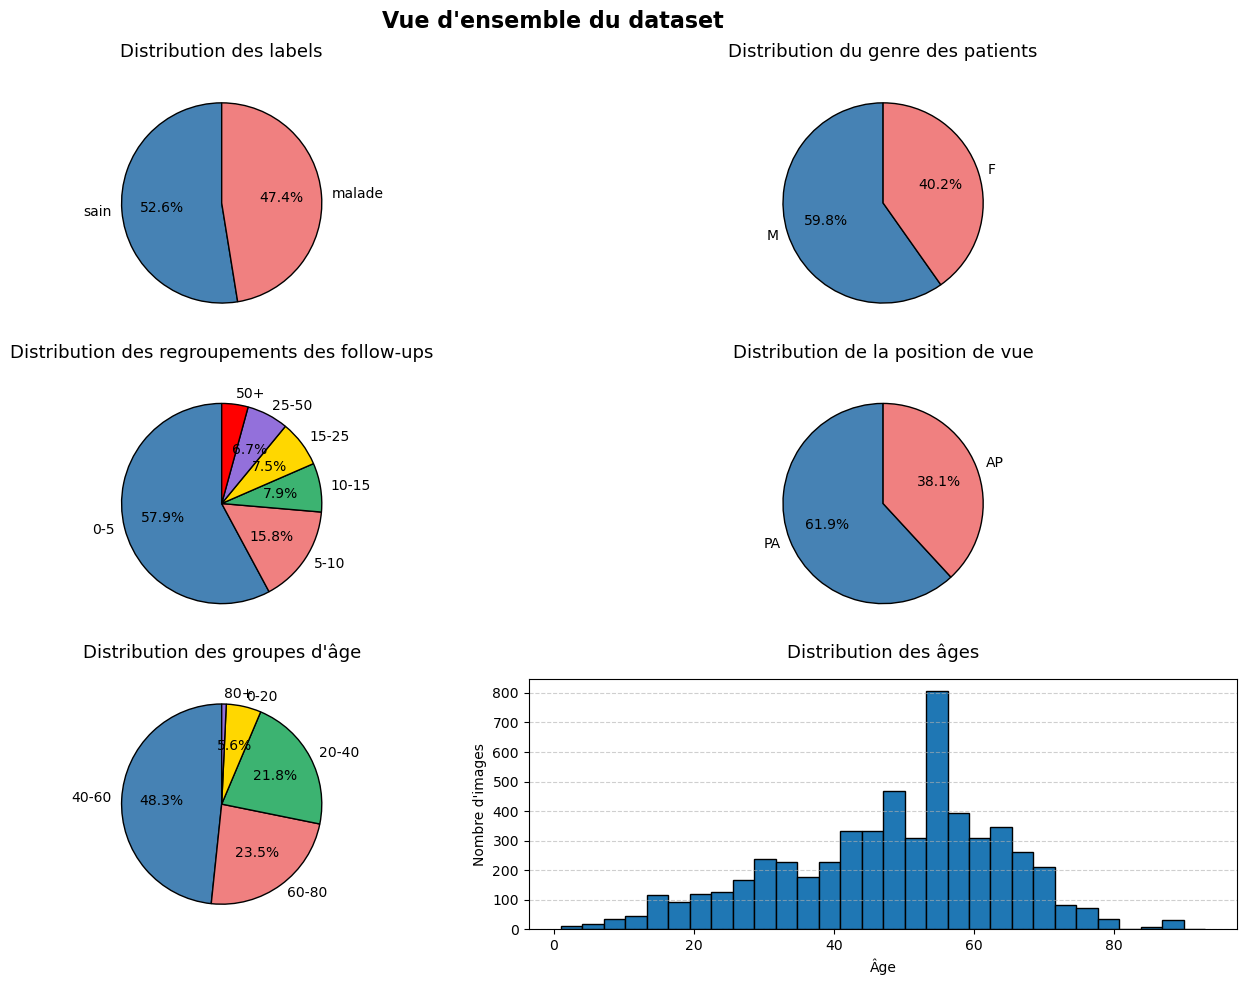

In [38]:
counts = [["label", "Patient Gender"], ["Follow-up_Group", "View Position"], ["Age_Group", "Patient Age"]]
titre = [["des labels", "du genre des patients"], ["des regroupements des follow-ups", "de la position de vue"], ["des groupes d'âge", "des âges"]]

fig, axes = plt.subplots(3, 2, figsize=(14,10))

for i in range(3):
    for j in range(2):
        if(i == 2 and j == 1):
            axes[i][j].hist(df[counts[i][j]], bins=30, edgecolor="black")
            axes[i][j].set_xlabel("Âge")
            axes[i][j].set_ylabel("Nombre d'images")
            axes[i][j].grid(axis="y", linestyle="--", alpha=0.6)
        else:
            axes[i][j].pie(
                df[counts[i][j]].value_counts(),
                labels = df[counts[i][j]].value_counts().index,
                autopct=lambda pct: f"{pct:.1f}%" if pct > 5 else "",
                startangle = 90,
                colors = ["steelblue", "lightcoral", "mediumseagreen", "gold", "mediumpurple", "red"] if ((i == 2 and j == 0) or (i == 1 and j == 0)) else ["steelblue", "lightcoral"],
                wedgeprops={"edgecolor": "black"},
            )

        axes[i][j].set_title(f"Distribution {titre[i][j]}", fontsize=13, pad=15)

fig.suptitle("Vue d'ensemble du dataset", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

L’analyse univariée a permis de caractériser la distribution de chaque variable (tendance centrale, dispersion, forme) et de détecter des déséquilibres entre certaines valeures.

L'analyse univariée sur le genre montre une légère prédominance des hommes sur les femmes, representés respectivement par 57% et 43% des observations.
Cela ne constitue pas un désequilibre majeur mais il faut le prendre en compte lors de l'analyse de biais.


# !!INTERPRETER!!

### B) Analyse bivariée

On va maintenant mettre en relation les données deux à deux et les analyser ainsi.

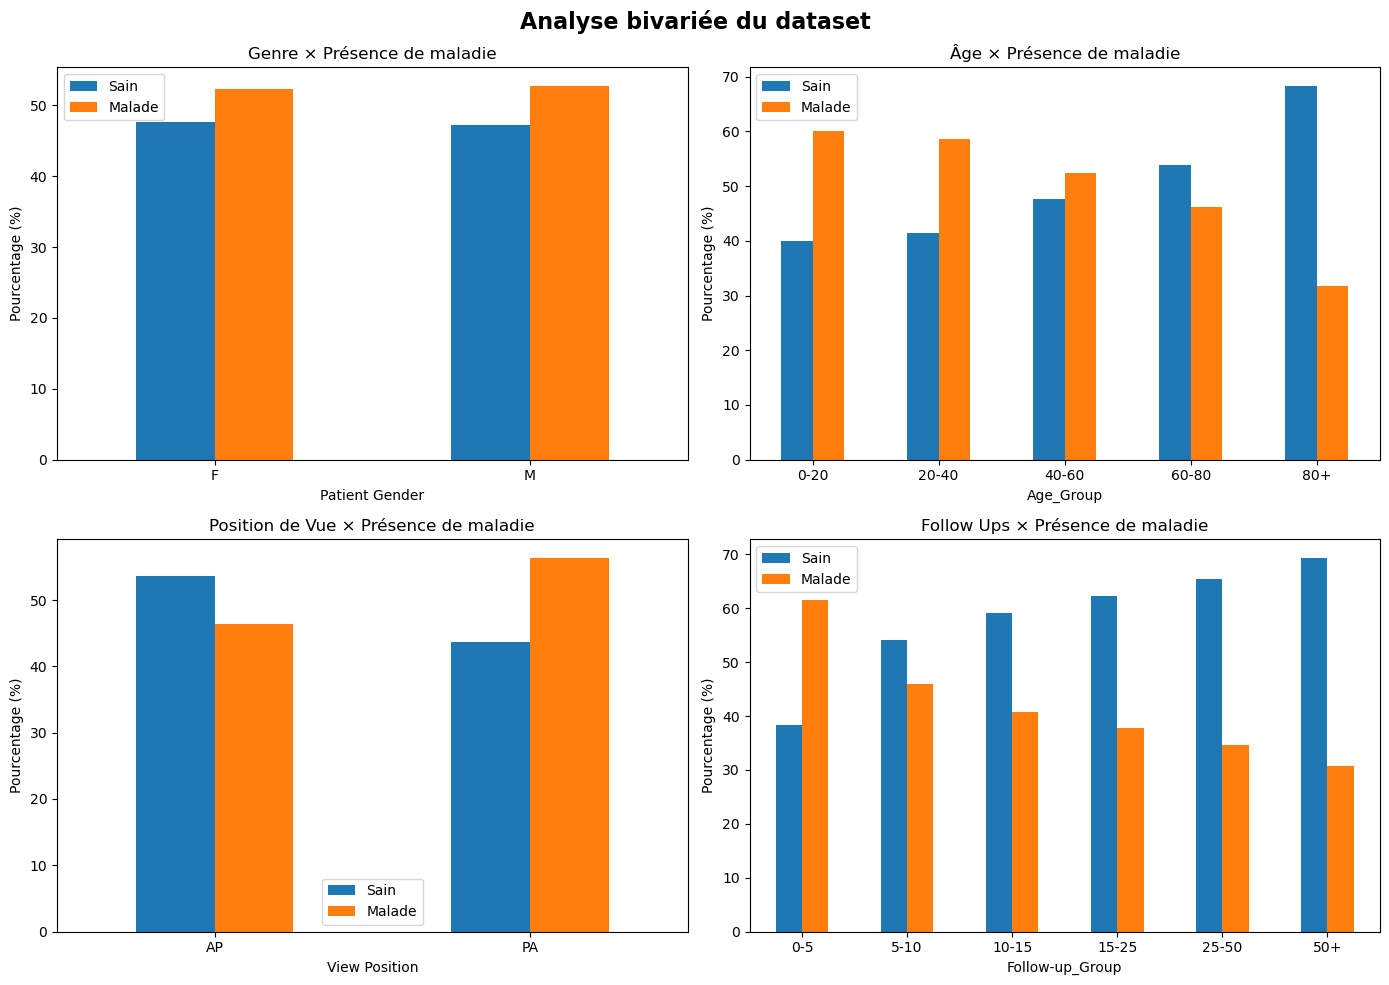

In [39]:
#Genre × Maladie
table_genre_maladie = pd.crosstab(
    df["Patient Gender"],
    df["label"],
    normalize="index"
) * 100

#Age_group × Maladie
table_age_maladie = pd.crosstab(
    df["Age_Group"],
    df["label"],
    normalize="index"
) * 100

#View Position × Maladie
table_View_maladie = pd.crosstab(
    df["View Position"],
    df["label"],
    normalize="index"
) * 100

#Follow ups × Maladie
table_Follow_maladie = pd.crosstab(
    df["Follow-up_Group"],
    df["label"],
    normalize="index"
) * 100

counts = [[table_genre_maladie, table_age_maladie], [table_View_maladie, table_Follow_maladie]]
titre = [["Genre × Présence de maladie", "Âge × Présence de maladie"], ["Position de Vue × Présence de maladie", "Follow Ups × Présence de maladie"]]

fig, axes = plt.subplots(2, 2, figsize=(14,10))

for i in range(2):
    for j in range(2):
        counts[i][j].plot(kind="bar", ax=axes[i][j])
        axes[i][j].set_ylabel("Pourcentage (%)")
        axes[i][j].tick_params(axis='x', rotation=0)
        axes[i][j].legend(["Sain", "Malade"])

        axes[i][j].set_title(titre[i][j])

fig.suptitle("Analyse bivariée du dataset", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()



#age*genre
#genre*view position
#age*view position
#genre*follow up
#age*follow up

#analyse triple

In [40]:
## analyse détaillée des résultats

print(f"Différence hommes - femmes : {(table_genre_maladie.loc["M", "malade"] - table_genre_maladie.loc["F", "malade"]):.2f}%")
contingence = pd.crosstab(df["Patient Gender"], df["label"])
chi2, p, dof, expected = chi2_contingency(contingence)

print("p-value :", p)
rr = table_genre_maladie.loc["M", "malade"] / table_genre_maladie.loc["F", "malade"]
print(rr)


# On prend comme groupe de référence le groupe d'âge 40-60 car c'est le groupe avec le plus de valeures et le plus stable statistiquement
print("\n")
print("\n")
print(table_age_maladie["malade"] - table_age_maladie["malade"]["40-60"])

contingence = pd.crosstab(df["Age_Group"],df["label"])
chi2, p, dof, expected = chi2_contingency(contingence)
print("\n")
print("p-value :", p)
print("\n")
rr = table_age_maladie / table_age_maladie["malade"]["40-60"]
print(rr)

Différence hommes - femmes : -0.45%
p-value : 0.7633824344663006
0.9906276458103747




Age_Group
0-20     -7.576767
20-40    -6.101357
40-60     0.000000
60-80     6.269387
80+      20.715916
Name: malade, dtype: float64


p-value : 7.813846093633881e-11


label        malade      sain
Age_Group                    
0-20       0.840747  1.261120
20-40      0.871758  1.230109
40-60      1.000000  1.101866
60-80      1.131774  0.970092
80+        1.435421  0.666445


Le test du χ² donne une p-value de 0.0196, inférieure au seuil de 5 %, ce qui indique que la relation entre le genre et la présence de maladie est statistiquement significative. Toutefois, l’écart observé entre les proportions reste modéré, ce qui suggère que l’effet est présent mais de faible ampleur.Le risk ratio est égal à 1.06, ce qui signifie que les hommes ont une probabilité environ 6 % plus élevée de présenter une pathologie que les femmes. Bien que statistiquement significative, cette différence reste modérée.

analyse manquante

# PreProcessing

On a vu plusieurs methods de preprocessing, mais dans le cas le modele avec lequelle on travaille prends en entree seulement les images, et pas les metadonnees.
C'es la raison que les methodes de DIR(Disperate Impact Remover) et LFR(Learn fair representations) ne sont pas appliquables , et le seul methode de Preprocessing qu'on peut appliquer est le Reweighting

On va comparer trois différentes versions :

- *Baseline* : résultats sans application du reweighting.
- *RW_Gender* : application du reweighting en utilisant le genre comme attribut sensible.
- *RW_Age* : application du reweighting en utilisant l’âge comme attribut sensible.

D’abord, définissons les méthodes que nous allons utiliser pour analyser les performances et les métriques de fairness.

In [41]:
import numpy as np
import pandas as pd
from datetime import datetime
from pathlib import Path

from IPython.display import Markdown, display
from aif360.datasets import StandardDataset
from aif360.algorithms.preprocessing import Reweighing
from aif360.sklearn.metrics import *
from sklearn.metrics import balanced_accuracy_score, accuracy_score

from train_classifieur import train_classifier, pred_classifier


def get_metrics(
    y_true, # list or np.array of truth values
    y_pred=None,  # list or np.array of predictions
    prot_attr=None, # list or np.array of protected/sensitive attribute values
    priv_group=1, # value taken by the privileged group
    pos_label=1, # value taken by the positive truth/prediction
    sample_weight=None # list or np.array of weights value,
):
    group_metrics = {}
    group_metrics["base_rate_truth"] = base_rate(
        y_true=y_true, pos_label=pos_label, sample_weight=sample_weight
    )
    group_metrics["statistical_parity_difference"] = statistical_parity_difference(
        y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, priv_group=priv_group, pos_label=pos_label, sample_weight=sample_weight
    )
    group_metrics["disparate_impact_ratio"] = disparate_impact_ratio(
        y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, priv_group=priv_group, pos_label=pos_label, sample_weight=sample_weight
    )
    if not y_pred is None:
        group_metrics["base_rate_preds"] = base_rate(
        y_true=y_pred, pos_label=pos_label, sample_weight=sample_weight
        )
        group_metrics["equal_opportunity_difference"] = equal_opportunity_difference(
            y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, priv_group=priv_group, pos_label=pos_label, sample_weight=sample_weight
        )
        group_metrics["average_odds_difference"] = average_odds_difference(
            y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, priv_group=priv_group, pos_label=pos_label, sample_weight=sample_weight
        )
        if len(set(y_pred))>1:
            group_metrics["conditional_demographic_disparity"] = conditional_demographic_disparity(
                y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, pos_label=pos_label, sample_weight=sample_weight
            )
        else:
            group_metrics["conditional_demographic_disparity"] =None
        group_metrics["smoothed_edf"] = smoothed_edf(
        y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, pos_label=pos_label, sample_weight=sample_weight
        )
        group_metrics["df_bias_amplification"] = df_bias_amplification(
        y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, pos_label=pos_label, sample_weight=sample_weight
        )
        group_metrics["balanced_accuracy_score"] = balanced_accuracy_score(
        y_true=y_true, y_pred=y_pred, sample_weight=sample_weight
        )
    return group_metrics


On repart de notre DataFrame nettoyé. On y ajoute des colonnes correspondant à des attributs binaires pour l’analyse de fairness

In [42]:
df_model = df.copy()

for weight_col in ["WEIGHTS"]:
    df_model[weight_col] = pd.to_numeric(df_model[weight_col], errors="coerce").fillna(1.0)

df_model["label_bin"] = (df_model["label"] == "malade").astype(int)
df_model["gender_bin"] = (df_model["Patient Gender"] == "M").astype(int)
df_model["age_bin"] = (df_model["Patient Age"] >= 60).astype(int)

df_model_train = df_model[df_model["train_valid"] == "train"].copy()
df_model_valid = df_model[df_model["train_valid"] == "valid"].copy()

print(f"Nombre d'images train : {len(df_model_train)}")
print(f"Nombre d'images valid : {len(df_model_valid)}")

df_model[["Image Index", "label", "WEIGHTS", "label_bin", "gender_bin", "age_bin"]].head()

Nombre d'images train : 4135
Nombre d'images valid : 1457


,Image Index,label,WEIGHTS,label_bin,gender_bin,age_bin
0,00000011_000.png,malade,1,1,1,1
1,00000011_001.png,sain,1,0,1,1
2,00000011_002.png,sain,1,0,1,1
3,00000011_003.png,sain,1,0,1,1
4,00000011_004.png,sain,1,0,1,1


On définit une méthode pour effectuer le reweighting.

In [43]:
def apply_reweighing(df_model, protected_col, output_weight_col):
    df_train = df_model[df_model["train_valid"] == "train"].copy()
    df_valid = df_model[df_model["train_valid"] == "valid"].copy()

    dataset_train = StandardDataset(
        df=df_train[["label_bin", protected_col, "WEIGHTS"]].copy(),
        label_name="label_bin",
        favorable_classes=[1],
        protected_attribute_names=[protected_col],
        privileged_classes=[[1]],
        instance_weights_name="WEIGHTS",
    )
    dataset_val = StandardDataset(
        df=df_valid[["label_bin", protected_col, "WEIGHTS"]].copy(),
        label_name="label_bin",
        favorable_classes=[1],
        protected_attribute_names=[protected_col],
        privileged_classes=[[1]],
        instance_weights_name="WEIGHTS",
    )

    sens_ind = 0
    sens_attr = dataset_train.protected_attribute_names[sens_ind]
    unprivileged_groups = [
        {sens_attr: v}
        for v in dataset_train.unprivileged_protected_attributes[sens_ind]
    ]
    privileged_groups = [
        {sens_attr: v}
        for v in dataset_train.privileged_protected_attributes[sens_ind]
    ]

    RW = Reweighing(
        unprivileged_groups=unprivileged_groups,
        privileged_groups=privileged_groups,
    )
    RW.fit(dataset_train)
    dataset_transf_train = RW.transform(dataset_train)
    dataset_transf_val = RW.transform(dataset_val)

    df_model.loc[df_train.index, output_weight_col] = dataset_transf_train.instance_weights
    df_model.loc[df_valid.index, output_weight_col] = dataset_transf_val.instance_weights

    return {
        "sens_attr": sens_attr,
        "unprivileged_groups": unprivileged_groups,
        "privileged_groups": privileged_groups,
        "dataset_train": dataset_transf_train,
        "dataset_val": dataset_transf_val,
    }



In [44]:
gender_reweighing = apply_reweighing(df_model, "gender_bin", "WEIGHTS_GENDER")
age_reweighing = apply_reweighing(df_model, "age_bin", "WEIGHTS_AGE")

reweighing_setup = pd.DataFrame(
    [
        {
            "Attribut": "genre",
            "Colonne poids": "WEIGHTS_GENDER",
            "Attribut sensible": gender_reweighing["sens_attr"],
            "Groupes non privilégiés": str(gender_reweighing["unprivileged_groups"]),
            "Groupes privilégiés": str(gender_reweighing["privileged_groups"]),
        },
        {
            "Attribut": "âge",
            "Colonne poids": "WEIGHTS_AGE",
            "Attribut sensible": age_reweighing["sens_attr"],
            "Groupes non privilégiés": str(age_reweighing["unprivileged_groups"]),
            "Groupes privilégiés": str(age_reweighing["privileged_groups"]),
        },
    ]
)
reweighing_setup


,Attribut,Colonne poids,Attribut sensible,Groupes non privilégiés,Groupes privilégiés
0,genre,WEIGHTS_GENDER,gender_bin,[{'gender_bin': np.float64(0.0)}],[{'gender_bin': np.float64(1.0)}]
1,âge,WEIGHTS_AGE,age_bin,[{'age_bin': np.float64(0.0)}],[{'age_bin': np.float64(1.0)}]


On vérifie que le reweighting a bien fonctionné et que l’on obtient des poids différents pour les différents exemples.

In [45]:
weight_check = pd.DataFrame(
    {
        "WEIGHTS": df_model["WEIGHTS"].describe(),
        "WEIGHTS_GENDER": df_model["WEIGHTS_GENDER"].describe(),
        "WEIGHTS_AGE": df_model["WEIGHTS_AGE"].describe(),
    }
)

assert df_model["WEIGHTS"].nunique() == 1
assert df_model["WEIGHTS_GENDER"].nunique() > 1
assert df_model["WEIGHTS_AGE"].nunique() > 1


weight_check

,WEIGHTS,WEIGHTS_GENDER,WEIGHTS_AGE
count,5592.0,5592.000000,5592.000000
mean,1.0,1.000292,0.999399
std,0.0,0.014819,0.068146
min,1.0,0.982578,0.888950
25%,1.0,0.988173,0.962500
50%,1.0,1.010712,0.962500
75%,1.0,1.010712,1.046022
max,1.0,1.020432,1.124385


On sauvegarde le jeu de données dans trois fichiers CSV pour entraîner le modèle.

In [47]:
run_root = Path("./expe_log")
run_root.mkdir(parents=True, exist_ok=True)

baseline_csv = run_root / "metadata_baseline.csv"
gender_csv = run_root / "metadata_gender.csv"
age_csv = run_root / "metadata_age.csv"

df_model.to_csv(baseline_csv, index=False)
df_model.to_csv(gender_csv, index=False)
df_model.to_csv(age_csv, index=False)


print("baseline", "CSV: ", str(baseline_csv))
print("Gender fair model", "CSV: ", str(gender_csv))
print("Age fair model", "CSV: ", str(age_csv))

baseline CSV:  expe_log/metadata_baseline.csv
Gender fair model CSV:  expe_log/metadata_gender.csv
Age fair model CSV:  expe_log/metadata_age.csv


On entraine le modele et fait des predictions

In [48]:

def train_and_predict(name, csv_path, weights_col, preds_col, run_root):
    logdir = run_root / name
    logdir.mkdir(parents=True, exist_ok=True)

    ckpt_path, ckpt_score = train_classifier(
        logdir=str(logdir),
        datadir=DATADIR,
        csv=str(csv_path),
        weights_col=weights_col,
    )

    preds_csv = logdir / f"{preds_col}.csv"
    pred_classifier(
        datadir=DATADIR,
        csv_in=str(csv_path),
        csv_out=str(preds_csv),
        ckpt_path=ckpt_path,
        preds_col=preds_col,
    )

    return {
        "name": name,
        "csv_path": csv_path,
        "weights_col": weights_col,
        "preds_col": preds_col,
        "logdir": logdir,
        "ckpt_path": ckpt_path,
        "ckpt_score": ckpt_score,
        "preds_csv": preds_csv,
    }



In [49]:
baseline_preds_csv = run_root / "baseline" / "preds_baseline.csv"
gender_preds_csv = run_root / "gender" / "preds_gender_rw.csv"
age_preds_csv = run_root / "age" / "preds_age_rw.csv"

if not baseline_preds_csv.exists():

    baseline_run = train_and_predict(
        name="baseline",
        csv_path=baseline_csv,
        weights_col="WEIGHTS",
        preds_col="preds_baseline",
        run_root=run_root,
    )
    baseline_preds_csv = baseline_run["preds_csv"]
if not gender_preds_csv.exists():

    gender_run = train_and_predict(
        name="gender",
        csv_path=gender_csv,
        weights_col="WEIGHTS_GENDER",
        preds_col="preds_gender_rw",
        run_root=run_root,
    )
    gender_preds_csv = gender_run["preds_csv"]
if not age_preds_csv.exists():
    age_run = train_and_predict(
        name="age",
        csv_path=age_csv,
        weights_col="WEIGHTS_AGE",
        preds_col="preds_age_rw",
        run_root=run_root,
    )
    age_preds_csv = age_run["preds_csv"]


experiment_rows = []
for exp_name, csv_path, pred_col, weight_col in [
    ("baseline", baseline_preds_csv, "preds_baseline", "WEIGHTS"),
    ("gender", gender_preds_csv, "preds_gender_rw", "WEIGHTS_GENDER"),
    ("age", age_preds_csv, "preds_age_rw", "WEIGHTS_AGE"),
]:
    df_pred = pd.read_csv(csv_path)
    df_valid = df_pred[df_pred["train_valid"] == "valid"].copy()

    df_valid["label_bin_eval"] = df_valid["labels"].map({"malade": 1, "sain": 0}).astype(int)
    df_valid["pred_bin_eval"] = df_valid[pred_col].map({"malade": 1, "sain": 0}).astype(int)

    sample_weight = None
    if weight_col in df_valid.columns:
        sample_weight = pd.to_numeric(df_valid[weight_col], errors="coerce").fillna(1.0)

    experiment_rows.append(
        {
            "Expérience": exp_name,
            "Poids": weight_col,
            "Prédictions": pred_col,
            "CSV": str(csv_path),
            "Nb valid": len(df_valid),
            "Accuracy valid": accuracy_score(
                df_valid["label_bin_eval"], df_valid["pred_bin_eval"], sample_weight=sample_weight
            ),
            "Balanced Accuracy valid": balanced_accuracy_score(
                df_valid["label_bin_eval"], df_valid["pred_bin_eval"], sample_weight=sample_weight
            ),
        }
    )

experiment_summary = pd.DataFrame(experiment_rows)
experiment_summary


,Expérience,Poids,Prédictions,CSV,Nb valid,Accuracy valid,Balanced Accuracy valid
0,baseline,WEIGHTS,preds_baseline,expe_log/baseline/preds_baseline.csv,1457,0.614962,0.618155
1,gender,WEIGHTS_GENDER,preds_gender_rw,expe_log/gender/preds_gender_rw.csv,1457,0.643819,0.644537
2,age,WEIGHTS_AGE,preds_age_rw,expe_log/age/preds_age_rw.csv,1457,0.642433,0.643358


In [50]:
### RUN IN COLAB ONLY

confirm = input("Are you sure you are running this on Colab ? Confirm with 'y'")
if confirm != 'y':
    raise ValueError("You must confirm you are running on Colab")
! cp -r ./expe_log/* /content/drive/MyDrive/fairness

ValueError: You must confirm you are running on Colab

Calculons les métriques de performance et de fairness, et comparons-les.

In [51]:

def build_comparison_table(baseline_valid, rw_valid, protected_eval_col, fairness_weight_col, method_label):
    baseline_metrics = get_metrics(
        y_true=baseline_valid["label_bin_eval"].to_numpy(),
        y_pred=baseline_valid["pred_bin_eval"].to_numpy(),
        prot_attr=baseline_valid[protected_eval_col].to_numpy(),
        pos_label=1,
        sample_weight=baseline_valid["WEIGHTS"].to_numpy(),
    )
    rw_metrics = get_metrics(
        y_true=rw_valid["label_bin_eval"].to_numpy(),
        y_pred=rw_valid["pred_bin_eval"].to_numpy(),
        prot_attr=rw_valid[protected_eval_col].to_numpy(),
        pos_label=1,
        sample_weight=rw_valid[fairness_weight_col].to_numpy(),
    )

    comparison = pd.DataFrame(
        [
            {
                "Method": "Baseline",
                "Accuracy": accuracy_score(
                    baseline_valid["label_bin_eval"],
                    baseline_valid["pred_bin_eval"],
                    sample_weight=baseline_valid["WEIGHTS"],
                ),
                "Balanced Accuracy": balanced_accuracy_score(
                    baseline_valid["label_bin_eval"],
                    baseline_valid["pred_bin_eval"],
                    sample_weight=baseline_valid["WEIGHTS"],
                ),
                "Statistical Parity Diff": baseline_metrics.get("statistical_parity_difference"),
                "Disparate Impact Ratio": baseline_metrics.get("disparate_impact_ratio"),
                "Equal Opportunity Diff": baseline_metrics.get("equal_opportunity_difference"),
                "Average Odds Diff": baseline_metrics.get("average_odds_difference"),
            },
            {
                "Method": method_label,
                "Accuracy": accuracy_score(
                    rw_valid["label_bin_eval"],
                    rw_valid["pred_bin_eval"],
                    sample_weight=rw_valid["WEIGHTS"],
                ),
                "Balanced Accuracy": balanced_accuracy_score(
                    rw_valid["label_bin_eval"],
                    rw_valid["pred_bin_eval"],
                    sample_weight=rw_valid["WEIGHTS"],
                ),
                "Statistical Parity Diff": rw_metrics.get("statistical_parity_difference"),
                "Disparate Impact Ratio": rw_metrics.get("disparate_impact_ratio"),
                "Equal Opportunity Diff": rw_metrics.get("equal_opportunity_difference"),
                "Average Odds Diff": rw_metrics.get("average_odds_difference"),
            },
        ]
    )
    return comparison, baseline_metrics, rw_metrics

In [52]:
baseline_results = pd.read_csv(baseline_preds_csv)
gender_results = pd.read_csv(gender_preds_csv)
age_results = pd.read_csv(age_preds_csv)

baseline_valid = baseline_results[baseline_results["train_valid"] == "valid"].copy()
gender_valid = gender_results[gender_results["train_valid"] == "valid"].copy()
age_valid = age_results[age_results["train_valid"] == "valid"].copy()

for df_eval, pred_col in [
    (baseline_valid, "preds_baseline"),
    (gender_valid, "preds_gender_rw"),
    (age_valid, "preds_age_rw"),
]:
    df_eval["label_bin_eval"] = df_eval["labels"].map({"malade": 1, "sain": 0}).astype(int)
    df_eval["pred_bin_eval"] = df_eval[pred_col].map({"malade": 1, "sain": 0}).astype(int)
    df_eval["gender_bin_eval"] = (df_eval["Patient Gender"] == "M").astype(int)
    df_eval["age_bin_eval"] = (df_eval["Patient Age"] >= 60).astype(int)
    for weight_col in ["WEIGHTS", "WEIGHTS_GENDER", "WEIGHTS_AGE"]:
        if weight_col in df_eval.columns:
            df_eval[weight_col] = pd.to_numeric(df_eval[weight_col], errors="coerce").fillna(1.0)

assert "preds_baseline" in baseline_valid.columns
assert "preds_gender_rw" in gender_valid.columns
assert "preds_age_rw" in age_valid.columns
assert len(baseline_valid) == len(gender_valid) == len(age_valid)

comparison_gender, baseline_gender_metrics, gender_rw_metrics = build_comparison_table(
    baseline_valid=baseline_valid,
    rw_valid=gender_valid,
    protected_eval_col="gender_bin_eval",
    fairness_weight_col="WEIGHTS_GENDER",
    method_label="Reweighing Gender",
)
display(comparison_gender.round(4))



comparison_age, baseline_age_metrics, age_rw_metrics = build_comparison_table(
    baseline_valid=baseline_valid,
    rw_valid=age_valid,
    protected_eval_col="age_bin_eval",
    fairness_weight_col="WEIGHTS_AGE",
    method_label="Reweighing Age",
)
display(comparison_age.round(4))



,Method,Accuracy,Balanced Accuracy,Statistical Parity Diff,Disparate Impact Ratio,Equal Opportunity Diff,Average Odds Diff
0,Baseline,0.6150,0.6182,-0.0531,0.9191,-0.0514,-0.0649
1,Reweighing Gender,0.6438,0.6446,0.0073,1.0139,-0.0070,-0.0116


,Method,Accuracy,Balanced Accuracy,Statistical Parity Diff,Disparate Impact Ratio,Equal Opportunity Diff,Average Odds Diff
0,Baseline,0.6150,0.6182,-0.1804,0.7676,-0.1283,-0.1534
1,Reweighing Age,0.6438,0.6455,-0.1118,0.8312,-0.0230,-0.0998


## Analysis

Après application du reweighting avec les attributs sensibles gender et age, on observe dans les deux cas une amélioration de l’accuracy. Le reweighting basé sur le genre conduit à une amélioration plus marquée des métriques d’équité. Pour l’âge, les métriques d’équité s’améliorent également, mais de manière plus limitée.

En conclusion, les résultats montrent que la méthode de reweighting permet d’améliorer à la fois les performances et les métriques de fairness pour les deux attributs sensibles. Cependant, l’amélioration est nettement plus marquée pour le genre, dont les métriques se rapprochent presque des valeurs idéales après reweighting. En revanche, bien que le reweighting appliqué à l’âge réduise le biais initial, les métriques de fairness restent plus éloignées des valeurs souhaitées. Cela suggère que le biais lié à l’âge est plus complexe à corriger et qu’une simple méthode de reweighting ne suffit pas à le atténuer complètement dans notre cas.